José Matheus Gonçalves Rodrigues  - GEC - 2171

# Projeto Prático de Machine Learning

## Objetivo
Desenvolver um projeto completo de Machine Learning aplicando os conceitos estudados ao longo do curso.

---

## Descrição

Você deverá construir um pipeline de Machine Learning, passando por todas as etapas necessárias:

- Análise dos dados  
- Pré-processamento  
- Treinamento de um modelo  
- Avaliação dos resultados  
- Interpretação dos resultados  

---

## Escolha do problema

Escolha um dos tipos abaixo:

### 1) Classificação
Exemplo: prever uma classe (spam/não spam, tipo de planta, etc.)

### 2) Regressão
Exemplo: prever um valor numérico (preço, temperatura, etc.)

### 3) Clustering
Exemplo: agrupar dados semelhantes (segmentação de clientes)

---

## Etapas obrigatórias

### 1) Análise dos dados
- Descreva o dataset  
- Identifique padrões, distribuições e possíveis problemas  

---

### 2) Pré-processamento
- Trate valores ausentes (se houver)  
- Realize normalização ou padronização  
- Codifique variáveis categóricas (se necessário)  
- Compare dados antes e depois do pré-processamento  

---

### 3) Modelagem
- Escolha um algoritmo adequado ao problema  
- Treine o modelo  
- Justifique sua escolha  

---

### 4) Avaliação

Dependendo do problema:

* Para classificação:
  - Percentual de acertos (quantos exemplos o modelo acertou)
  - Análise dos erros (quais tipos de exemplos foram mais difíceis)
  - Matriz de confusão (se desejar, como ferramenta visual)

* Para regressão:
  - Comparação entre valores reais e valores previstos
  - Análise visual dos erros (diferença entre o valor real e o previsto)
  - Discussão sobre se o modelo está “próximo” ou “longe” dos valores reais

* Para clustering:
  - Visualização dos grupos formados
  - Análise se os grupos fazem sentido na prática
  - Interpretação dos padrões encontrados

---

### 5) Conclusões
Responda:

- O modelo teve bom desempenho?  
- O pré-processamento influenciou o resultado?  
- O modelo seria útil em um cenário real?  

---

## Entrega

- Notebook (.ipynb) completo  
- Código organizado  
- Gráficos e análises  
- Comentários explicando as decisões  

---

## Importante
Não foque apenas no código.  
Explique seu raciocínio em cada etapa do projeto.

# Neste projeto, será desenvolvido um sistema de análise de dados utilizando técnicas de Aprendizado de Máquina aplicadas a sinais de radiofrequência (RF). O principal objetivo é estimar a distância de um objeto com base em características extraídas do sinal recebido, como RSSI, potência recebida, relação sinal-ruído (SNR), frequência de operação e largura de banda.


Os parametros seriam:


*   Frequencia_GHz

*  Potencia_tx_dBm

*   Potencia_rx_dBm
*  Rssi_dBm


*   Snr_dB


*   Largura_banda_MHz

* Material
   
O modelo quer prever:


*   distancia_m











# 1. Análise dos dados

In [2]:
import numpy as np  # Importa a biblioteca NumPy
import pandas as pd  # Importa a biblioteca Pandas

np.random.seed(42)  # Define uma semente

n_amostras = 300  # Define a quantidade total de amostras que serão geradas

distancia_m = np.random.uniform(1, 20, n_amostras)  # Gera distâncias aleatórias entre 1 e 20 metros

frequencia_GHz = np.random.choice([2.4, 3.5, 5.8], n_amostras)  # Escolhe aleatoriamente frequências

potencia_tx_dBm = np.random.choice([0, 5, 10, 15], n_amostras)  # Escolhe aleatoriamente potências transmitidas

largura_banda_MHz = np.random.choice([20, 30, 40, 80], n_amostras)  # Escolhe aleatoriamente larguras de banda

material = np.random.choice(["metal", "plastico", "madeira", "vidro"], n_amostras)  # Escolhe aleatoriamente o material do objeto

perda_por_distancia = 20 * np.log10(distancia_m)  # Calcula uma perda aproximada do sinal em função da distância

efeito_material = np.where(material == "metal", -8,  # Define maior perda para objetos metálicos
                  np.where(material == "vidro", -5,  # Define perda intermediária para objetos de vidro
                  np.where(material == "madeira", -3, -2)))  # Define perda menor para madeira e plástico

ruido = np.random.normal(0, 2, n_amostras)  # Gera ruído aleatório com média 0 e desvio padrão 2

potencia_rx_dBm = potencia_tx_dBm - perda_por_distancia + efeito_material + ruido  # Calcula a potência recebida simulada

rssi_dBm = potencia_rx_dBm + np.random.normal(0, 1.5, n_amostras)  # Simula o RSSI adicionando pequenas variações à potência recebida

snr_dB = rssi_dBm - np.random.normal(-85, 3, n_amostras)  # Calcula uma estimativa da relação sinal-ruído

df = pd.DataFrame({  # Cria um DataFrame para organizar os dados
    "frequencia_GHz": frequencia_GHz,
    "potencia_tx_dBm": potencia_tx_dBm,
    "potencia_rx_dBm": potencia_rx_dBm,
    "rssi_dBm": rssi_dBm,
    "snr_dB": snr_dB,
    "largura_banda_MHz": largura_banda_MHz,
    "material": material,
    "distancia_m": distancia_m
})

df.head()  # Exibe as cinco primeiras linhas do dataset

,frequencia_GHz,potencia_tx_dBm,potencia_rx_dBm,rssi_dBm,snr_dB,largura_banda_MHz,material,distancia_m
0,2.4,15,-8.868870,-6.342978,78.175300,20,plastico,8.116262
1,3.5,15,-16.163239,-16.851566,68.139296,80,madeira,19.063572
2,5.8,0,-32.717958,-31.099937,52.589249,40,metal,14.907885
3,5.8,0,-23.798379,-23.856142,57.571920,30,plastico,12.374511
4,5.8,5,-10.928131,-11.187072,70.964266,20,vidro,3.964354


In [3]:
df.info() # Exibe informações gerais do dataset
df.describe()
df.isnull().sum()
df["material"].value_counts()
df.corr(numeric_only=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   frequencia_GHz     300 non-null    float64
 1   potencia_tx_dBm    300 non-null    int64  
 2   potencia_rx_dBm    300 non-null    float64
 3   rssi_dBm           300 non-null    float64
 4   snr_dB             300 non-null    float64
 5   largura_banda_MHz  300 non-null    int64  
 6   material           300 non-null    object 
 7   distancia_m        300 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 18.9+ KB


,frequencia_GHz,potencia_tx_dBm,potencia_rx_dBm,rssi_dBm,snr_dB,largura_banda_MHz,distancia_m
frequencia_GHz,1.000000,0.017822,0.010343,0.008547,0.020283,-0.042078,0.010015
potencia_tx_dBm,0.017822,1.000000,0.578421,0.576869,0.561937,0.018507,0.031784
potencia_rx_dBm,0.010343,0.578421,1.000000,0.985869,0.930630,0.007862,-0.686373
rssi_dBm,0.008547,0.576869,0.985869,1.000000,0.945887,0.005747,-0.675228
snr_dB,0.020283,0.561937,0.930630,0.945887,1.000000,-0.029127,-0.642662
largura_banda_MHz,-0.042078,0.018507,0.007862,0.005747,-0.029127,1.000000,-0.037851
distancia_m,0.010015,0.031784,-0.686373,-0.675228,-0.642662,-0.037851,1.000000


# 2. Pré processamento
Nesta etapa, foi realizado o pré-processamento dos dados para preparar o dataset para o treinamento do modelo de regressão. Inicialmente, a coluna distancia_m foi separada como variável alvo, pois representa o valor que o modelo deverá prever. As demais colunas foram utilizadas como variáveis de entrada.

In [4]:
from sklearn.model_selection import train_test_split  # Importa a função para separar dados
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Importa ferramentas para tratar texto e normalizar números
from sklearn.compose import ColumnTransformer  # Permite aplicar transformações diferentes em colunas diferentes
from sklearn.pipeline import Pipeline  # Organiza as etapas de pré-processamento em sequência

X = df.drop("distancia_m", axis=1)  # Separa as variáveis de entrada, removendo a coluna alvo
y = df["distancia_m"]  # Define a variável alvo, que é a distância do objeto

colunas_numericas = [
    "frequencia_GHz",
    "potencia_tx_dBm",
    "potencia_rx_dBm",
    "rssi_dBm",
    "snr_dB",
    "largura_banda_MHz"
]  # Lista as colunas numéricas do dataset

colunas_categoricas = ["material"]  # Lista a coluna categórica do dataset

preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),  # Normaliza as variáveis numéricas
        ("cat", OneHotEncoder(), colunas_categoricas)  # Converte a variável material em valores numéricos
    ]
)  # Cria o pré-processador com as transformações necessárias

X_train, X_test, y_train, y_test = train_test_split(
    X,  # Dados de entrada
    y,  # Dados de saída
    test_size=0.2,  # Separa 20% dos dados para teste
    random_state=42  # Garante que a divisão seja sempre igual
)  # Divide o dataset em treino e teste

In [5]:
print(df.isnull().sum())  # Verifica a quantidade de valores ausentes no dataset

# A análise mostra que o dataset não possui valores nulos
# Isso indica que os dados estão completos para o treinamento

print(X.head())  # Exibe os dados antes do pré-processamento

# Observa-se que a variável "material" está em formato textual
# Também é possível notar diferenças de escala entre os atributos numéricos

X_processado = preprocessador.fit_transform(X)  # Aplica o pré-processamento nos dados

X_processado_df = pd.DataFrame(
    X_processado,
    columns=preprocessador.get_feature_names_out()
)

X_processado_df.head()
# Após o pré-processamento: Todas as variáveis tornam-se numéricas e os dados ficam preparados para o treinamento do modelo.

print(X_processado_df.head())  # Exibe o formato dos dados após o tratamento



frequencia_GHz       0
potencia_tx_dBm      0
potencia_rx_dBm      0
rssi_dBm             0
snr_dB               0
largura_banda_MHz    0
material             0
distancia_m          0
dtype: int64
   frequencia_GHz  potencia_tx_dBm  potencia_rx_dBm   rssi_dBm     snr_dB  \
0             2.4               15        -8.868870  -6.342978  78.175300   
1             3.5               15       -16.163239 -16.851566  68.139296   
2             5.8                0       -32.717958 -31.099937  52.589249   
3             5.8                0       -23.798379 -23.856142  57.571920   
4             5.8                5       -10.928131 -11.187072  70.964266   

   largura_banda_MHz  material  
0                 20  plastico  
1                 80   madeira  
2                 40     metal  
3                 30  plastico  
4                 20     vidro  
   num__frequencia_GHz  num__potencia_tx_dBm  num__potencia_rx_dBm  \
0            -0.942297              1.525323              0.796067   
1 

# 3) Modelagem

O modelo Random Forest Regressor foi escolhido porque consegue aprender relações complexas e não lineares entre parâmetros de radiofrequência, como RSSI, SNR, potência recebida, frequência e material do objeto, permitindo estimar a distância do objeto a partir do comportamento do sinal RF, mesmo em ambientes com ruído, perdas de propagação, reflexão e interferências, sendo uma abordagem adequada para aplicações modernas de telecomunicações, IoT e redes B5G/6G.

In [7]:
from sklearn.model_selection import train_test_split  # Importa a função para separar treino e teste
from sklearn.ensemble import RandomForestRegressor  # Importa o modelo de regressão Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Importa métricas de avaliação
import numpy as np  # Importa o NumPy para cálculos matemáticos

X_train, X_test, y_train, y_test = train_test_split(
    X_processado,  # Usa os dados já pré-processados, sem textos
    y,  # Variável alvo
    test_size=0.2,  # Separa 20% dos dados para teste
    random_state=42  # Mantém os resultados reproduzíveis
)

modelo = RandomForestRegressor(
    n_estimators=100,  # Define a quantidade de árvores
    random_state=42  # Mantém o resultado reproduzível
)
modelo.fit(X_train, y_train)  # Treina o modelo com os dados de treino
y_pred = modelo.predict(X_test)  # Faz previsões com os dados de teste
mae = mean_absolute_error(y_test, y_pred)  # Calcula o erro médio absoluto
mse = mean_squared_error(y_test, y_pred)  # Calcula o erro quadrático médio
rmse = np.sqrt(mse)  # Calcula a raiz do erro quadrático médio
r2 = r2_score(y_test, y_pred)  # Calcula o R² do modelo
print("MAE:", mae)  # Exibe o MAE
print("MSE:", mse)  # Exibe o MSE
print("RMSE:", rmse)  # Exibe o RMSE
print("R²:", r2)  # Exibe o R²

MAE: 2.13942303648355
MSE: 8.26262136839757
RMSE: 2.874477581822055
R²: 0.7124628203458616


O modelo apresentou MAE de aproximadamente 2,14 metros.
Isso significa que, em média, a previsão da distância erra cerca de 2 metros.
O RMSE foi de aproximadamente 2,87 metros.
Como o RMSE penaliza mais erros grandes, ele indica que existem algumas previsões com erro maior.

O R² foi de aproximadamente 0,71.
Isso indica que o modelo conseguiu explicar cerca de 71% da variação da distância.

Portanto, o Random Forest Regressor apresentou um desempenho razoável,
mostrando que os atributos de RF possuem relação com a distância do objeto.

# 4. Avaliação

     Valor_Real  Valor_Previsto
203   18.072530       14.826481
266   14.243299       12.275244
152    3.753003        4.023808
9     14.453379       14.400227
233   10.357836        8.834147
226   19.487201       17.521323
196   14.793158       15.519134
109    2.462618        4.963029
5      3.963896        7.809307
175    4.312962        4.238235
Erro médio absoluto: 2.13942303648355


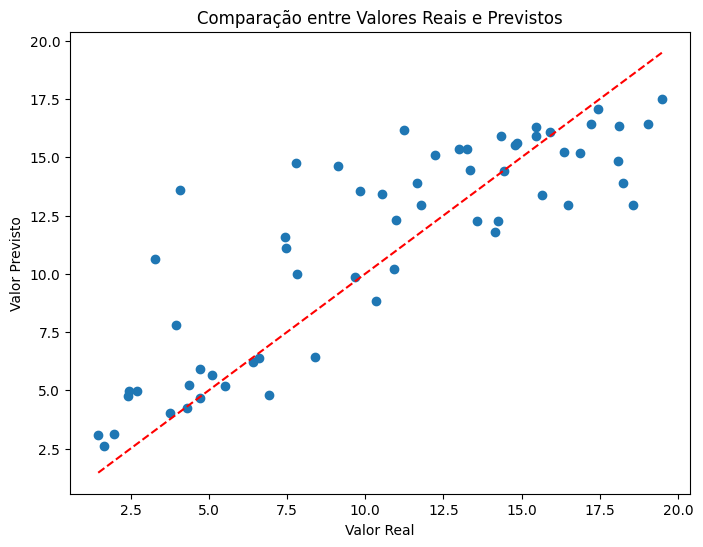

In [8]:
import matplotlib.pyplot as plt

comparacao = pd.DataFrame({
    "Valor_Real": y_test,  # Valores reais da distância
    "Valor_Previsto": y_pred  # Valores previstos pelo modelo
})

print(comparacao.head(10))  # Exibe as primeiras comparações entre valores reais e previstos
erro_absoluto = np.abs(y_test - y_pred)  # Calcula o erro absoluto entre valor real e previsto
print("Erro médio absoluto:", erro_absoluto.mean())  # Exibe a média dos erros absolutos
plt.figure(figsize=(8,6))  # Define o tamanho do gráfico
plt.scatter(y_test, y_pred)  # Cria um gráfico de dispersão entre valores reais e previstos
plt.xlabel("Valor Real")  # Nome do eixo X
plt.ylabel("Valor Previsto")  # Nome do eixo Y
plt.title("Comparação entre Valores Reais e Previstos")  # Título do gráfico
plt.plot(
    [y_test.min(), y_test.max()],  # Define o início e fim da linha
    [y_test.min(), y_test.max()],
    'r--'
)  # Desenha uma linha de referência

plt.show()  # Exibe o gráfico


# Conclusão

 O modelo apresentou desempenho satisfatório para um dataset sintético de RF.
 O valor de R² mostrou que o modelo conseguiu explicar boa parte da variação da distância do objeto utilizando os parâmetros de radiofrequência.
O MAE e o RMSE indicaram que o erro médio das previsões ficou em tornode poucos metros, mostrando que o modelo conseguiu aprender padrões relevantesentre RSSI, potência recebida, SNR e distância.
O pré-processamento influenciou diretamente no desempenho do modelo. A normalização ajudou a reduzir diferenças de escala entre os atributos numéricos.Além disso, a codificação categórica permitiu que o modelo utilizasseinformações relacionadas ao material do objeto.
O Random Forest Regressor apresentou bons resultados porque consegue lidacom relações não lineares e padrões complexos presentes em sinais de RF.




Observação:
O código e os comentários deste notebook foram propositalmente
detalhados para fins de estudo, aprendizado
e consulta futura do próprio autor.
O objetivo é facilitar o entendimento de cada etapa do pipeline
de Machine Learning, desde a construção do dataset até a avaliação
final do modelo.